In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os
import json
import k3d
import time
import lc_reconstruction_analysis.utils as utils
import lc_reconstruction_analysis.dendritic as dendritic
import lc_reconstruction_analysis.clustering as clustering
import lc_reconstruction_analysis.axon as axon
import lc_reconstruction_analysis.correlation as correlation
%matplotlib inline

## Assemble data

In [2]:
DATA_DIR = Path("../data/LC_Snapshots")
BASE_DIR = Path("../data/")
SAVE_DIR = Path("../results/")

In [3]:
dataDF, graphs = utils.load_cells(DATA_DIR)

### Plotting example reconstructions

In [4]:
from lc_reconstruction_analysis.k3d_plotter import *

# Get CCF lookups
acronym_to_id = utils.get_acronym_to_id()

In [5]:
# Plot example single neurons shown in Fig 2
plotGraphs = ['N023-685222', 'N047-685221', 'N065-685221', 'N022-648434', 'N045-685221', 'N059-685221']

for name in plotGraphs:
    plot = k3d.plot()
    plot_ccf_mesh(acronym_to_id['root'], plot, color=rgb_to_hex(128,128,128), opacity=0.05)
    plot_graphs([graphs[name]],plot, opacity = .8)
    
    # Set camera
    plot.grid_visible = False
    plot.display()
    time.sleep(0.5) # let display render before setting camera
    plot.camera = sideviewHorizontal

    # Save interactable html file
    time.sleep(0.5) # let display render before snapping screenshot
    with open(SAVE_DIR.joinpath(f'figure 2 - reconstruction {name}.html'), 'w') as f:
        f.write(plot.get_snapshot())

Output()

Output()

Output()

Output()

Output()

Output()

## Assemble dataframes of relevant features

In [6]:
# Projection regions to look at
sorted_rois = ["OLF","Isocortex","HPF","CTXsp","CNU","TH","HY","MB","CB","P","MY","Other"]

In [7]:
# Build length dataframe
lengthDF = clustering.build_length_df(dataDF,graphs,BASE_DIR,normalize_df=False)
lengthDF.head(3)

,CB,fiber tracts,CNU,Isocortex,HPF,TH,CTXsp,OLF,MB,VS,HY,MY,P,Other
N023-648434,196.708809,6270.365039,10109.785796,165630.135953,26892.087087,1555.214412,6588.476763,14897.175038,2715.969006,189.273142,1004.714358,2534.338477,2118.452415,2428.099251
N011-648434,660.795271,3962.072177,3093.499273,144114.880852,3256.811865,254.587430,0.000000,1740.741340,3584.200736,579.763271,2450.942886,190.824797,3683.083336,1132.467291
N021-648434,10518.956587,9786.549970,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2999.475232,121.343431,0.000000,1160.181570,1067.272280,0.000000


In [8]:
# Get basic features, e.g. branching and length
axon_branch_dict = {}
dend_branch_dict = {}
dend_length_dict = {}
for name in dataDF["Graph"]:
    graph = graphs[name]
    # Get axonal branches
    axon_branch_nodes = [node for node in graph.nodes() if graph.out_degree(node) > 1 and graph.nodes[node]["structure_id"] == 2]
    axon_branch_dict[name] = len(axon_branch_nodes)
    # Get dendritic branches
    dend_branch_nodes = [node for node in graph.nodes() if graph.out_degree(node) > 1 and graph.nodes[node]["structure_id"] == 3] # get dendritic branches
    dend_branch_dict[name] = len(dend_branch_nodes)
    # Get dendritic lengths
    dend_graph = graph.subgraph([node for node in graph.nodes() if (graph.nodes[node]["structure_id"] == 3) or (graph.nodes[node]["structure_id"] == 1)])
    dend_length_dict[name] = sum(dend_graph[u][v]["weight"] for u, v in dend_graph.edges) # total length

# Combine length and branching into one dataframe
metricsDF = pd.concat([pd.Series(lengthDF.sum(axis=1) / 10000, name = "Axon Length (cm)"),
            pd.Series(axon_branch_dict, name = "Axon Branches"), 
            pd.Series(dend_length_dict, name = "Dendrite Length (cm)") / 10000,
            pd.Series(dend_branch_dict, name = "Dendrite Branches")], axis = 1)
metricsDF.head(3)

,Axon Length (cm),Axon Branches,Dendrite Length (cm),Dendrite Branches
N023-648434,24.313080,345,0.320355,5
N011-648434,16.870467,136,0.442497,8
N021-648434,2.565378,20,0.275511,5


In [9]:
# Merge dataframes
featureDF = pd.merge(dataDF,metricsDF,left_on="Graph", right_index=True, how = "left")

In [10]:
# Get normalized features
normDF = pd.concat([lengthDF.divide(lengthDF.sum(axis = 1), axis = 0)[sorted_rois],
                    pd.Series(metricsDF["Axon Length (cm)"] / metricsDF["Axon Length (cm)"].max(), name = "Norm Axon Length"),
                    pd.Series(metricsDF["Axon Branches"] / metricsDF["Axon Branches"].max(), name = "Norm Axon Branches"),
                    pd.Series(metricsDF["Dendrite Length (cm)"] / metricsDF["Dendrite Length (cm)"].max(), name = "Norm Dend Length"),
                    pd.Series(metricsDF["Dendrite Branches"] / metricsDF["Dendrite Branches"].max(), name = "Norm Dend Branches")], axis = 1)
normDF.head(3)

,OLF,Isocortex,HPF,CTXsp,CNU,TH,HY,MB,CB,P,MY,Other,Norm Axon Length,Norm Axon Branches,Norm Dend Length,Norm Dend Branches
N023-648434,0.061272,0.681239,0.110607,0.027098,0.041582,0.006397,0.004132,0.011171,0.000809,0.008713,0.010424,0.009987,0.345725,0.224609,0.420316,0.106383
N011-648434,0.010318,0.854244,0.019305,0.000000,0.018337,0.001509,0.014528,0.021245,0.003917,0.021832,0.001131,0.006713,0.239893,0.088542,0.580570,0.170213
N021-648434,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.116921,0.410035,0.041603,0.045225,0.000000,0.036479,0.013021,0.361480,0.106383


In [11]:
normDF.loc[["N012-721332", "N003-721332", "N016-721332"]]

,OLF,Isocortex,HPF,CTXsp,CNU,TH,HY,MB,CB,P,MY,Other,Norm Axon Length,Norm Axon Branches,Norm Dend Length,Norm Dend Branches
N012-721332,0.000000,0.000376,0.016554,0.0,0.000000,0.018361,0.003535,0.191685,0.431117,0.075148,0.118365,0.031443,0.459054,0.272135,0.501549,0.234043
N003-721332,0.333095,0.000000,0.000000,0.0,0.073802,0.002417,0.030752,0.026392,0.387867,0.031485,0.000000,0.005078,0.208778,0.114583,0.457941,0.340426
N016-721332,0.000000,0.000000,0.013748,0.0,0.000000,0.000106,0.000000,0.214056,0.216889,0.157526,0.198610,0.089133,0.224722,0.107422,0.382865,0.234043


In [12]:
# Get normalized features
normDF = pd.concat([lengthDF.divide(lengthDF.sum(axis = 1), axis = 0)[sorted_rois],
                    pd.Series(metricsDF["Axon Length (cm)"] / metricsDF["Axon Length (cm)"].max(), name = "Norm Axon Length"),
                    pd.Series(metricsDF["Axon Branches"] / metricsDF["Axon Branches"].max(), name = "Norm Axon Branches"),
                    pd.Series(metricsDF["Dendrite Length (cm)"] / metricsDF["Dendrite Length (cm)"].max(), name = "Norm Dend Length"),
                    pd.Series(metricsDF["Dendrite Branches"] / metricsDF["Dendrite Branches"].max(), name = "Norm Dend Branches")], axis = 1)
normDF.head(3)

,OLF,Isocortex,HPF,CTXsp,CNU,TH,HY,MB,CB,P,MY,Other,Norm Axon Length,Norm Axon Branches,Norm Dend Length,Norm Dend Branches
N023-648434,0.061272,0.681239,0.110607,0.027098,0.041582,0.006397,0.004132,0.011171,0.000809,0.008713,0.010424,0.009987,0.345725,0.224609,0.420316,0.106383
N011-648434,0.010318,0.854244,0.019305,0.000000,0.018337,0.001509,0.014528,0.021245,0.003917,0.021832,0.001131,0.006713,0.239893,0.088542,0.580570,0.170213
N021-648434,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.116921,0.410035,0.041603,0.045225,0.000000,0.036479,0.013021,0.361480,0.106383


In [13]:
# Merge dataframes
fullDF = pd.merge(featureDF,normDF,left_on="Graph", right_index=True, how = "left")
fullDF["Most Length"] = [sorted_rois[i] for i in np.argmax(fullDF[sorted_rois],axis=1)] # Add top projection target

## Projection figures

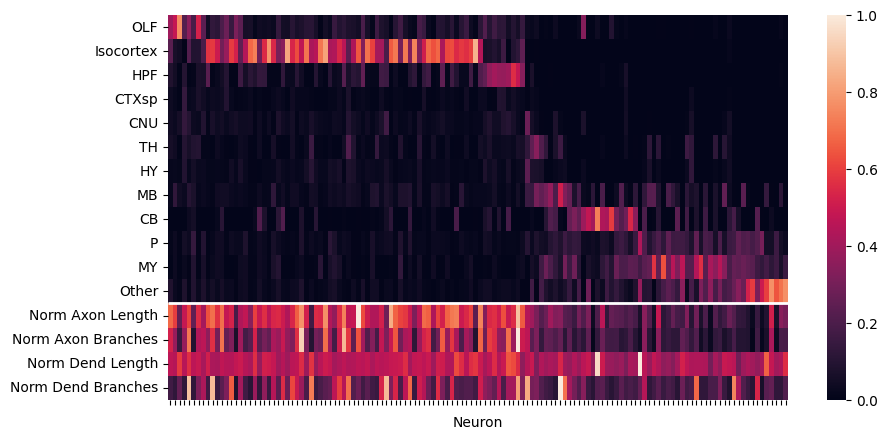

In [14]:
# Plot heatmap of projections
plotDF = fullDF.copy()
# Establish projection based sorting
sortProjDict = {}
for i, col in enumerate(sorted_rois):
    sortProjDict[col] = i
plotDF["Most Length"] = plotDF["Most Length"].map(sortProjDict)
plotDF = plotDF.sort_values("Most Length")[normDF.columns]

# Do plotting
plt.figure(figsize=(10,5))
sns.heatmap(plotDF.T, xticklabels = True, yticklabels = True)
# Clean up axes
plt.gca().set_xticklabels([])
plt.xlabel("Neuron")
plt.hlines([12], *plt.xlim(), colors = "white", linewidth = 2)
plt.savefig(SAVE_DIR.joinpath("figure 2 - projection heatmap sorted by top projection target.svg"),
            dpi=300,bbox_inches='tight', transparent = True)

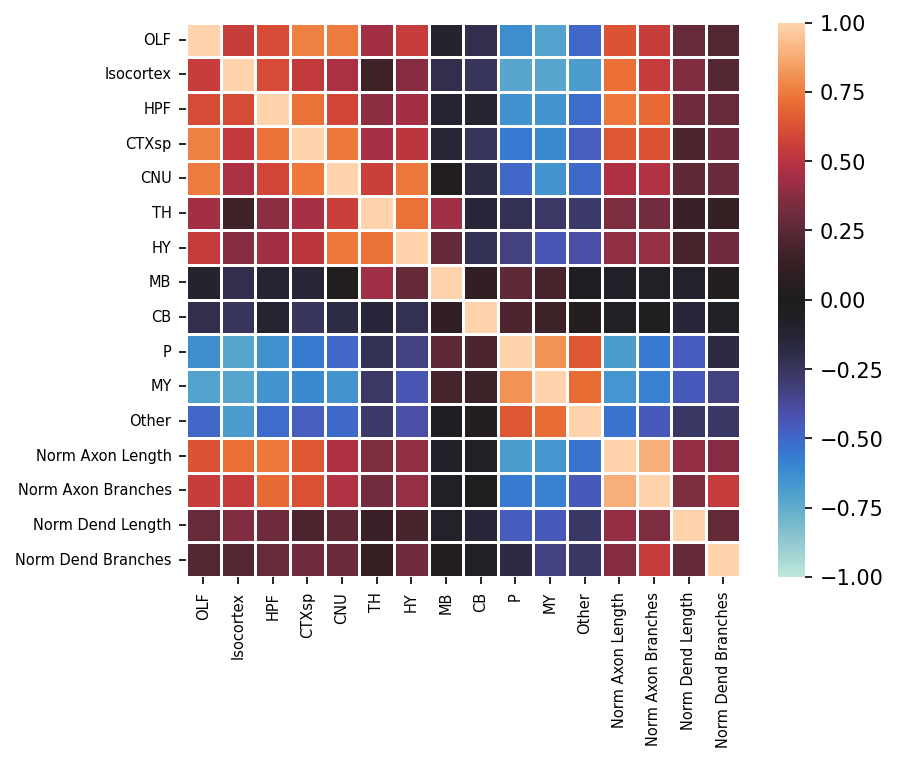

In [15]:
# Get correlation between features
corr_features = normDF.columns
corrMatrix = fullDF[corr_features].corr(method = "spearman")

# Do plotting
plt.figure(dpi=150)
sns.heatmap(corrMatrix, square = True, linewidths=.5, vmin = -1, vmax = 1, center = 0, cmap = "icefire")
plt.xticks(fontsize=7);
plt.yticks(fontsize=7);
plt.savefig(SAVE_DIR.joinpath("figure 2 - correlation matrix (spearman, proj + neuron features, diverging cmap).svg"),
            dpi=300, bbox_inches='tight', transparent = True)

### Plot neurons colored by soma position

In [16]:
useSC = False
feature = "somaDV"

# Plot with or without full spinal cord projections, which may increase visual clarity
if useSC:
    plotDF = dataDF.copy()
else:
    plotDF = dataDF[~dataDF["completeSC"]].copy()

# Setup colors, and normalize plotting values
cmap = sns.color_palette("viridis", as_cmap=True)
nMin = 4200
nMax = 5000
normVals = (plotDF[feature] - nMin) / (nMax - nMin)
normVals = normVals.clip(0,1).rename("normVal")
# normVals = norm_values.clip(0,1).rename("normVal")
plotDF = pd.merge(plotDF, normVals, left_index=True, right_index=True)

# Do plotting
plot = k3d.plot()
plot_ccf_mesh(acronym_to_id['root'], plot, color=rgb_to_hex(128,128,128), opacity=0.05)
for i, row in plotDF.iterrows():
    graph = graphs[row["Graph"]]
    r, g, b, _ = cmap(row["normVal"])
    color = rgb_to_hex(int(r*255),int(g*255), int(b*255))
    plot_graphs([graph],plot, color, opacity = .8, width = 1)

# Set camera
plot.grid_visible = False
plot.display()
time.sleep(0.5) # let display render before setting camera
plot.camera = sideviewHorizontal

Output()

In [17]:
with open(SAVE_DIR.joinpath("figure 2 - axons colored by DV soma position.html"), 'w') as f:
   f.write(plot.get_snapshot())

### Spatial distribution of top projection targets

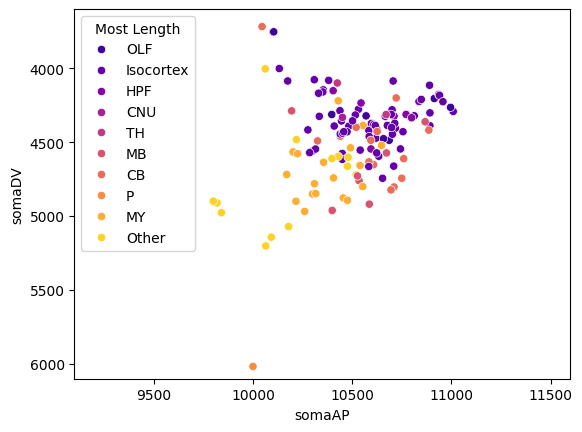

In [18]:
# Plot top projection target

# Only create colors for rois that are a top projection target
used_rois = sorted_rois.copy()
for indx in set(sorted_rois) - set(fullDF["Most Length"]):
    used_rois.remove(indx)

# Plot 
plt.figure()
sns.scatterplot(fullDF,x = "somaAP", y = "somaDV", hue = "Most Length", palette = "plasma", hue_order= used_rois)
plt.xlim([9100, 11600])
plt.ylim([3600, 6100])
plt.gca().invert_yaxis() # Invert the y-axis
plt.savefig(SAVE_DIR.joinpath("figure 2 - top projection target sagittal soma location.svg"),dpi=300, bbox_inches='tight')

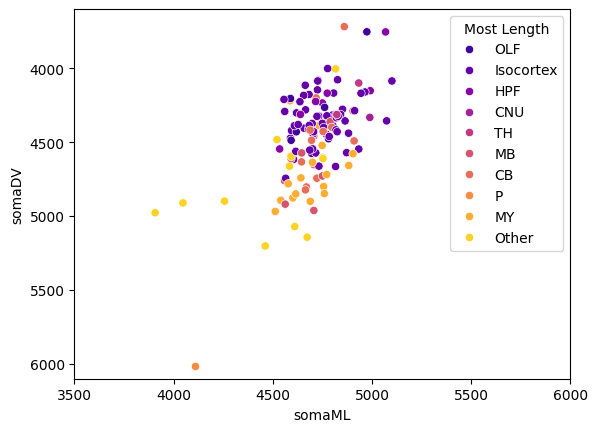

In [19]:
# Plot
plt.figure()
sns.scatterplot(fullDF,x = "somaML", y = "somaDV", hue = "Most Length", palette = "plasma", hue_order= used_rois)
plt.xlim([3500, 6000])
plt.ylim([3600, 6100])
plt.gca().invert_yaxis() # Invert the y-axis
plt.savefig(SAVE_DIR.joinpath("figure 2 - top projection target coronal soma location.svg"),dpi=300, bbox_inches='tight')